Scrapping

In [1]:
import pandas as pd
import numpy as np
import re
import string
from nltk.tokenize import word_tokenize
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
from google.colab import drive
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import precision_score, recall_score, f1_score
from scipy.sparse import csr_matrix, hstack
import random
import csv
import ast  # buat konversi string ke list jika perlu
!pip install seaborn
import seaborn as sns
import matplotlib.pyplot as plt

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
data = pd.read_csv('/content/drive/MyDrive/data/scrapping_baru.csv')

if 'content' not in data.columns:
    raise KeyError("The dataset does not contain a 'content' column.")

In [6]:
import pandas as pd

# Baca dataset kamu (ganti nama file sesuai file kamu)
df = pd.read_csv('/content/drive/MyDrive/data/scrapping_baru.csv')

# Pastikan kolom rating ada dan bernama 'rating'
# Kalau namanya beda, ganti sesuai kolom kamu
print(df.columns)  # cek dulu nama kolom

# Kelompokkan rating jadi dua kategori
def label_sentiment(score):
    if score in [1, 2]:
        return 'Negatif'
    elif score in [3, 4, 5]:
        return 'Positif'

df['kategori'] = df['score'].apply(label_sentiment)

# Hitung jumlah masing-masing kategori
sentiment_count = df['kategori'].value_counts()
sentiment_percent = df['kategori'].value_counts(normalize=True) * 100

# Tampilkan hasil
print("Jumlah masing-masing kategori:")
print(sentiment_count)
print("\nPersentase masing-masing kategori (%):")
print(sentiment_percent)

# (Opsional) buat tabel ringkas
result = pd.DataFrame({
    'Jumlah': sentiment_count,
    'Persentase (%)': sentiment_percent.round(2)
})

print("\nTabel hasil pengelompokan:")
print(result)


Index(['score', 'content'], dtype='object')
Jumlah masing-masing kategori:
kategori
Positif    8234
Negatif    1766
Name: count, dtype: int64

Persentase masing-masing kategori (%):
kategori
Positif    82.34
Negatif    17.66
Name: proportion, dtype: float64

Tabel hasil pengelompokan:
          Jumlah  Persentase (%)
kategori                        
Positif     8234           82.34
Negatif     1766           17.66


# Preprocessing


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   score    10000 non-null  int64 
 1   content  10000 non-null  object
dtypes: int64(1), object(1)
memory usage: 156.4+ KB


Case folding

In [8]:
def case_folding(content):
    return str(content).lower()

data['case_folding'] = data['content'].apply(case_folding)
print("Case Folding Completed")

display(data[['content', 'case_folding']].head(10))

Case Folding Completed


,content,case_folding
0,good website,good website
1,lumayan...,lumayan...
2,"iklan jalan pulangnya jangan diup terus dong, ...","iklan jalan pulangnya jangan diup terus dong, ..."
3,buat TIX maju trus dan sukses selalu dan serta...,buat tix maju trus dan sukses selalu dan serta...
4,aplikasinya sangat membantu,aplikasinya sangat membantu
5,👍,👍
6,penipuannn babiii a,penipuannn babiii a
7,niceeeee,niceeeee
8,aplikasi yang sangat berguna dan membantu pert...,aplikasi yang sangat berguna dan membantu pert...
9,bgus sekli,bgus sekli


Data Cleaning

In [9]:
def cleaning(content):
    content = str(content)
    content = re.sub(r'http\S+|www\S+', '', content)               # hapus link
    content = re.sub(r'\@\w+', '', content)                        # hapus mention
    content = re.sub(r'\d+', '', content)                          # hapus angka
    content = content.translate(str.maketrans('', '', string.punctuation))  # hapus tanda baca
    content = re.sub(r'\s+', ' ', content)                         # hapus spasi berlebihan
    content = re.sub(r'[^\w\s]', '', content, flags=re.UNICODE)               # hapus emoji dan karakter non-ASCII
    return content

data['cleaning'] = data['case_folding'].apply(cleaning)
print("Cleaning Completed")

display(data[['case_folding', 'cleaning']].head(10))


Cleaning Completed


,case_folding,cleaning
0,good website,good website
1,lumayan...,lumayan
2,"iklan jalan pulangnya jangan diup terus dong, ...",iklan jalan pulangnya jangan diup terus dong k...
3,buat tix maju trus dan sukses selalu dan serta...,buat tix maju trus dan sukses selalu dan serta...
4,aplikasinya sangat membantu,aplikasinya sangat membantu
5,👍,
6,penipuannn babiii a,penipuannn babiii a
7,niceeeee,niceeeee
8,aplikasi yang sangat berguna dan membantu pert...,aplikasi yang sangat berguna dan membantu pert...
9,bgus sekli,bgus sekli


In [10]:
# Pastikan tidak ada NaN atau nilai kosong dalam pipeline sebelum masuk tokenizer
data = data.dropna(subset=['cleaning'])  # hapus NaN
data = data[~data['cleaning'].astype(str).str.strip().eq("")]  # hapus string kosong

In [12]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9831 entries, 0 to 9999
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   score         9831 non-null   int64 
 1   content       9831 non-null   object
 2   case_folding  9831 non-null   object
 3   cleaning      9831 non-null   object
dtypes: int64(1), object(3)
memory usage: 384.0+ KB


Tokenisasi

In [13]:
def tokenize(content):
    return str(content).split()

data['tokenisasi'] = data['cleaning'].apply(tokenize)
print("Tokenization Completed")

display(data[['cleaning', 'tokenisasi']].head(10))

Tokenization Completed


,cleaning,tokenisasi
0,good website,"[good, website]"
1,lumayan,[lumayan]
2,iklan jalan pulangnya jangan diup terus dong k...,"[iklan, jalan, pulangnya, jangan, diup, terus,..."
3,buat tix maju trus dan sukses selalu dan serta...,"[buat, tix, maju, trus, dan, sukses, selalu, d..."
4,aplikasinya sangat membantu,"[aplikasinya, sangat, membantu]"
6,penipuannn babiii a,"[penipuannn, babiii, a]"
7,niceeeee,[niceeeee]
8,aplikasi yang sangat berguna dan membantu pert...,"[aplikasi, yang, sangat, berguna, dan, membant..."
9,bgus sekli,"[bgus, sekli]"
10,diskon terus ya,"[diskon, terus, ya]"


Normalisasi

In [14]:
# pake encoding biar file bisa dibaca dengan benar
normalization_dict = pd.read_csv('/content/drive/MyDrive/data/kamus_normalisasi_barulagi.csv', sep=';', encoding='ISO-8859-1')
normalization_dict = dict(zip(normalization_dict['before'], normalization_dict['after']))

def normalized_words(content):
    return [normalization_dict.get(word, word) for word in content]

data['normalisasi'] = data['tokenisasi'].apply(normalized_words)
data[['tokenisasi','normalisasi']].head(10)

,tokenisasi,normalisasi
0,"[good, website]","[good, website]"
1,[lumayan],[lumayan]
2,"[iklan, jalan, pulangnya, jangan, diup, terus,...","[iklan, jalan, pulangnya, jangan, diup, terus,..."
3,"[buat, tix, maju, trus, dan, sukses, selalu, d...","[buat, tix, maju, terus, dan, sukses, selalu, ..."
4,"[aplikasinya, sangat, membantu]","[aplikasinya, sangat, membantu]"
6,"[penipuannn, babiii, a]","[penipuannn, babi, a]"
7,[niceeeee],[nice]
8,"[aplikasi, yang, sangat, berguna, dan, membant...","[aplikasi, yang, sangat, berguna, dan, membant..."
9,"[bgus, sekli]","[bagus, sekali]"
10,"[diskon, terus, ya]","[diskon, terus, iya]"


Stopword

In [15]:
stop_words = set(stopwords.words('indonesian'))
def remove_stopwords(content):
    return [word for word in content if word not in stop_words]

data['stopword_removal'] = data['normalisasi'].apply(remove_stopwords)
print("Stopword Removal Completed")

display(data[['normalisasi', 'stopword_removal']].head(10))

Stopword Removal Completed


,normalisasi,stopword_removal
0,"[good, website]","[good, website]"
1,[lumayan],[lumayan]
2,"[iklan, jalan, pulangnya, jangan, diup, terus,...","[iklan, jalan, pulangnya, diup, minat, nonton,..."
3,"[buat, tix, maju, terus, dan, sukses, selalu, ...","[tix, maju, sukses, sertai, memberikn, tontona..."
4,"[aplikasinya, sangat, membantu]","[aplikasinya, membantu]"
6,"[penipuannn, babi, a]","[penipuannn, babi, a]"
7,[nice],[nice]
8,"[aplikasi, yang, sangat, berguna, dan, membant...","[aplikasi, berguna, membantu, pertahankan]"
9,"[bagus, sekali]",[bagus]
10,"[diskon, terus, iya]","[diskon, iya]"


Stemming

In [16]:
!pip install Sastrawi
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 5.1 MB/s eta 0:00:00


In [17]:
factory = StemmerFactory()
stemmer = factory.create_stemmer()

def stemming(content):
    if isinstance(content, list):
        return [stemmer.stem(word) for word in content if isinstance(word, str) and word.isalpha()]
    return []

data['stemming'] = data['stopword_removal'].apply(stemming)
print("Stemming Completed")

display(data[['stopword_removal', 'stemming']].head(10))

Stemming Completed


,stopword_removal,stemming
0,"[good, website]","[good, website]"
1,[lumayan],[lumayan]
2,"[iklan, jalan, pulangnya, diup, minat, nonton,...","[iklan, jalan, pulang, diup, minat, nonton, fi..."
3,"[tix, maju, sukses, sertai, memberikn, tontona...","[tix, maju, sukses, serta, memberikn, tonton, ..."
4,"[aplikasinya, membantu]","[aplikasi, bantu]"
6,"[penipuannn, babi, a]","[penipuannn, babi, a]"
7,[nice],[nice]
8,"[aplikasi, berguna, membantu, pertahankan]","[aplikasi, guna, bantu, tahan]"
9,[bagus],[bagus]
10,"[diskon, iya]","[diskon, iya]"


In [18]:
# Buat kolom baru hasil preprocessing
data["hasil_preprocessing"] = data["stemming"]

# Simpan full data
data.to_csv('/content/drive/MyDrive/data/hasil/TixID_Full_Data.csv', index=False)

# Simpan kolom hasil stemming aja
data["hasil_preprocessing"].to_csv('/content/drive/MyDrive/data/hasil/Clean_Data.csv', index=False)

# nampilin
data


,score,content,case_folding,cleaning,tokenisasi,normalisasi,stopword_removal,stemming,hasil_preprocessing
0,5,good website,good website,good website,"[good, website]","[good, website]","[good, website]","[good, website]","[good, website]"
1,4,lumayan...,lumayan...,lumayan,[lumayan],[lumayan],[lumayan],[lumayan],[lumayan]
2,1,"iklan jalan pulangnya jangan diup terus dong, ...","iklan jalan pulangnya jangan diup terus dong, ...",iklan jalan pulangnya jangan diup terus dong k...,"[iklan, jalan, pulangnya, jangan, diup, terus,...","[iklan, jalan, pulangnya, jangan, diup, terus,...","[iklan, jalan, pulangnya, diup, minat, nonton,...","[iklan, jalan, pulang, diup, minat, nonton, fi...","[iklan, jalan, pulang, diup, minat, nonton, fi..."
3,5,buat TIX maju trus dan sukses selalu dan serta...,buat tix maju trus dan sukses selalu dan serta...,buat tix maju trus dan sukses selalu dan serta...,"[buat, tix, maju, trus, dan, sukses, selalu, d...","[buat, tix, maju, terus, dan, sukses, selalu, ...","[tix, maju, sukses, sertai, memberikn, tontona...","[tix, maju, sukses, serta, memberikn, tonton, ...","[tix, maju, sukses, serta, memberikn, tonton, ..."
4,5,aplikasinya sangat membantu,aplikasinya sangat membantu,aplikasinya sangat membantu,"[aplikasinya, sangat, membantu]","[aplikasinya, sangat, membantu]","[aplikasinya, membantu]","[aplikasi, bantu]","[aplikasi, bantu]"
...,...,...,...,...,...,...,...,...,...
9995,1,Kenapa mau pesen tiket kok bermasalah terus ga...,kenapa mau pesen tiket kok bermasalah terus ga...,kenapa mau pesen tiket kok bermasalah terus ga...,"[kenapa, mau, pesen, tiket, kok, bermasalah, t...","[kenapa, mau, pesan, tiket, kok, bermasalah, t...","[pesan, tiket, bermasalah, iya]","[pesan, tiket, masalah, iya]","[pesan, tiket, masalah, iya]"
9996,2,Perbaiki dong kok eror terus,perbaiki dong kok eror terus,perbaiki dong kok eror terus,"[perbaiki, dong, kok, eror, terus]","[perbaiki, dong, kok, eror, terus]","[perbaiki, eror]","[baik, eror]","[baik, eror]"
9997,1,Erorrrr,erorrrr,erorrrr,[erorrrr],[erorrrr],[erorrrr],[erorrrr],[erorrrr]
9998,4,bagus tp ini mau nonton apknya malah tidak men...,bagus tp ini mau nonton apknya malah tidak men...,bagus tp ini mau nonton apknya malah tidak men...,"[bagus, tp, ini, mau, nonton, apknya, malah, t...","[bagus, tapi, ini, mau, nonton, aplikasi, bahk...","[bagus, nonton, aplikasi, menanggapi, hadeuh]","[bagus, nonton, aplikasi, tanggap, hadeuh]","[bagus, nonton, aplikasi, tanggap, hadeuh]"


In [19]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9831 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   score                9831 non-null   int64 
 1   content              9831 non-null   object
 2   case_folding         9831 non-null   object
 3   cleaning             9831 non-null   object
 4   tokenisasi           9831 non-null   object
 5   normalisasi          9831 non-null   object
 6   stopword_removal     9831 non-null   object
 7   stemming             9831 non-null   object
 8   hasil_preprocessing  9831 non-null   object
dtypes: int64(1), object(8)
memory usage: 768.0+ KB


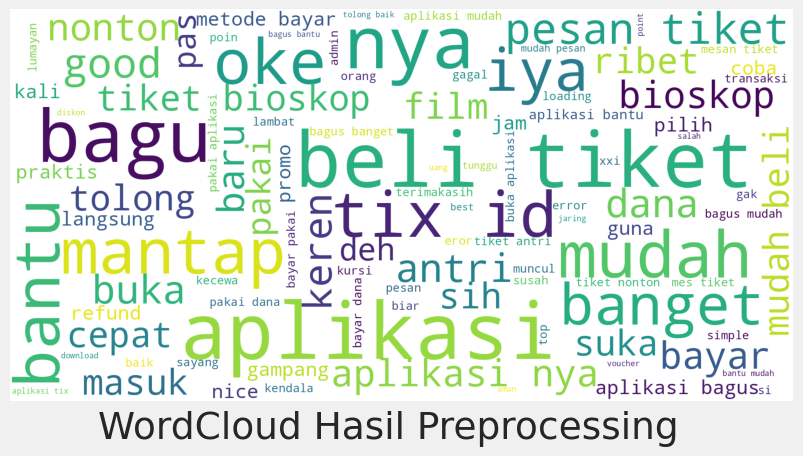

In [20]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt
import seaborn as sns

stopwords = set(STOPWORDS)
sns.set(style='whitegrid')
plt.style.use('fivethirtyeight')

def wordcloud(data, title=None):
    # Gabungkan list of tokens jadi string
    combined_text = ' '.join([' '.join(words) for words in data if isinstance(words, list)])

    wordcloud = WordCloud(
        background_color='white',
        stopwords=stopwords,
        max_words=100,
        max_font_size=40,
        scale=4,
        random_state=25
    ).generate(combined_text)

    fig = plt.figure(5, figsize=(9, 10))
    plt.axis('off')
    if title:
        fig.suptitle(title, fontsize=27)
        fig.subplots_adjust(top=2.3)
    plt.imshow(wordcloud)
    plt.show()

# Panggil fungsi
wordcloud(data['hasil_preprocessing'], title="WordCloud Hasil Preprocessing")


# Labeling

Labeling

In [21]:
# --- BACA KAMUS POSITIF DAN NEGATIF ---
lexicons_positive = dict()
with open('/content/drive/MyDrive/data/positive - positive.csv', 'r') as csvfile:
    reader = csv.reader(csvfile, delimiter=',')
    for row in reader:
        word = row[0].strip().lower()
        value = int(row[1])
        if len(word.split()) == 1:
            lexicons_positive[word] = value

lexicons_negative = dict()
with open('/content/drive/MyDrive/data/negative - negative.csv', 'r') as csvfile:
    reader = csv.reader(csvfile, delimiter=',')
    for row in reader:
        word = row[0].strip().lower()
        value = int(row[1])
        if len(word.split()) == 1:
            lexicons_negative[word] = -abs(value)

print(f"Jumlah kata dalam lexicon positif: {len(lexicons_positive)}")
print(f"Jumlah kata dalam lexicon negatif: {len(lexicons_negative)}")


# ---FUNGSI PENILAIAN SENTIMEN ---
def determine_lexicon_score(text):
    if isinstance(text, list):
        positive_score = sum(lexicons_positive.get(word.lower().strip(), 0) for word in text)
        negative_score = sum(lexicons_negative.get(word.lower().strip(), 0) for word in text)
        lexicon_score = positive_score + negative_score
        polarity = 'positif' if lexicon_score >= 0 else 'negatif'
        return lexicon_score, polarity
    return 0, 'negatif'


# --- APLIKASIKAN KE DATA ---
results = data["hasil_preprocessing"].apply(determine_lexicon_score)
results = list(zip(*results))

data['polarity_score'] = results[0]
data['polarity'] = results[1]

print(data['polarity'].value_counts())


# ---SIMPAN DATA ---
data.to_csv('/content/drive/MyDrive/data/hasil/TixID_label.csv', index=False)
data[["hasil_preprocessing", "polarity_score", "polarity"]].to_csv('/content/drive/MyDrive/data/hasil/dataset_polarity.csv', index=False)


Jumlah kata dalam lexicon positif: 3369
Jumlah kata dalam lexicon negatif: 6106
polarity
positif    6141
negatif    3690
Name: count, dtype: int64


In [22]:
data[['hasil_preprocessing', 'polarity_score', 'polarity']].head(10)

,hasil_preprocessing,polarity_score,polarity
0,"[good, website]",5,positif
1,[lumayan],-1,negatif
2,"[iklan, jalan, pulang, diup, minat, nonton, fi...",-9,negatif
3,"[tix, maju, sukses, serta, memberikn, tonton, ...",10,positif
4,"[aplikasi, bantu]",-5,negatif
6,"[penipuannn, babi, a]",-4,negatif
7,[nice],4,positif
8,"[aplikasi, guna, bantu, tahan]",-5,negatif
9,[bagus],-2,negatif
10,"[diskon, iya]",2,positif


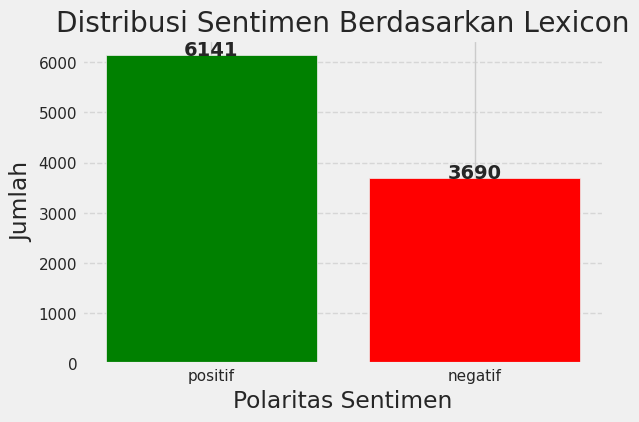

In [23]:
# Hitung jumlah masing-masing kategori sentimen dari hasil lexicon
sentiment_counts = data['polarity'].value_counts()

# Plot
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.bar(sentiment_counts.index, sentiment_counts.values, color=['green', 'red'])
plt.title('Distribusi Sentimen Berdasarkan Lexicon')
plt.xlabel('Polaritas Sentimen')
plt.ylabel('Jumlah')
plt.grid(axis='y', linestyle='--', alpha=0.7)
for i, v in enumerate(sentiment_counts.values):
    plt.text(i, v + 1, str(v), ha='center', fontweight='bold')
plt.show()

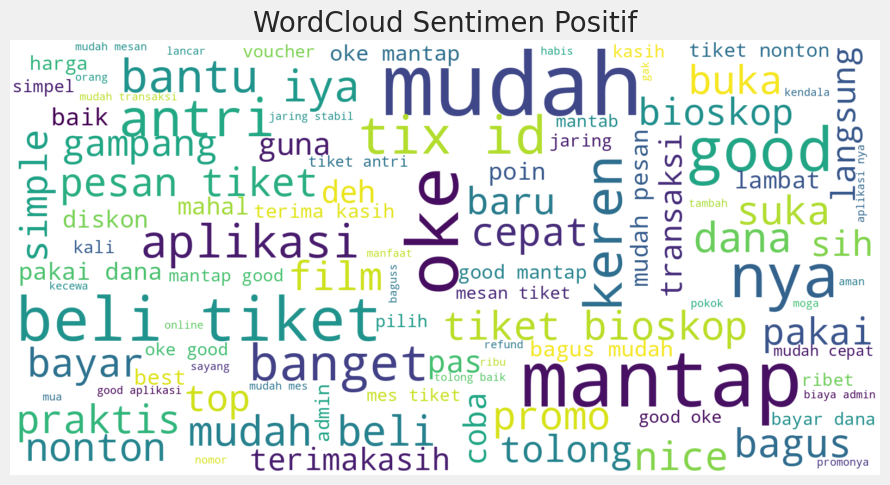

In [24]:
stopwords = set(STOPWORDS)
sns.set(style='whitegrid')
plt.style.use('fivethirtyeight')

def generate_wordcloud(data_series, title=None):
    # Gabungkan semua kata dari list ke string
    combined_text = ' '.join([' '.join(words) for words in data_series if isinstance(words, list)])

    wordcloud = WordCloud(
        background_color='white', stopwords=stopwords, max_words=100,
        max_font_size=40, scale=4, random_state=25
    ).generate(combined_text)

    # Plot
    plt.figure(figsize=(10, 8))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    if title:
        plt.title(title, fontsize=20)
    plt.show()

# WordCloud untuk sentimen positif
generate_wordcloud(data[data['polarity'] == 'positif']['hasil_preprocessing'], title='WordCloud Sentimen Positif')

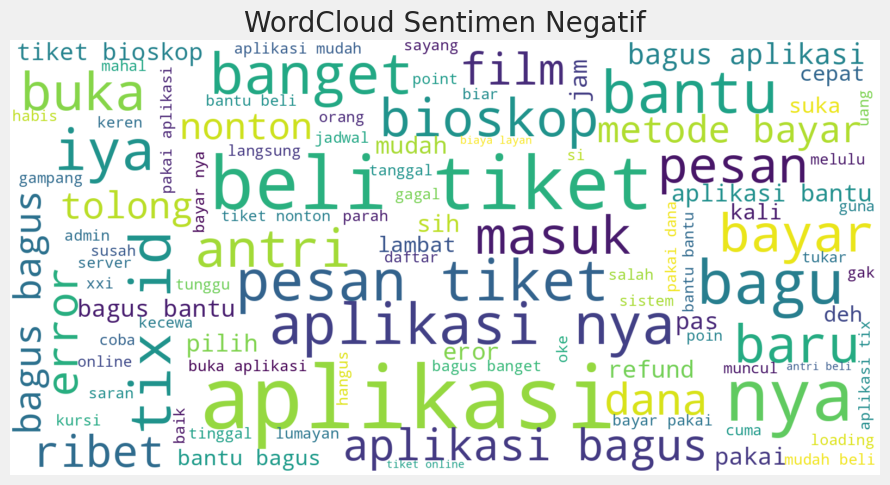

In [25]:
stopwords = set(STOPWORDS)
sns.set(style='whitegrid')
plt.style.use('fivethirtyeight')

def generate_wordcloud(data_series, title=None):
    # Gabungkan semua kata dari list ke string
    combined_text = ' '.join([' '.join(words) for words in data_series if isinstance(words, list)])

    wordcloud = WordCloud(
        background_color='white', stopwords=stopwords, max_words=100,
        max_font_size=40, scale=4, random_state=25
    ).generate(combined_text)

    # Plot
    plt.figure(figsize=(10, 8))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    if title:
        plt.title(title, fontsize=20)
    plt.show()

# WordCloud untuk sentimen negatif
generate_wordcloud(data[data['polarity'] == 'negatif']['hasil_preprocessing'], title='WordCloud Sentimen Negatif')

# Processing


Splitting

In [26]:
import ast
from sklearn.model_selection import train_test_split
import pandas as pd

# Load dan siapkan data - Load the full data instead of just the clean data
data_full = pd.read_csv('/content/drive/MyDrive/data/hasil/dataset_polarity.csv')

# Ubah list string jadi list Python - Apply ast.literal_eval to the correct column
data_full['hasil_preprocessing'] = data_full['hasil_preprocessing'].apply(ast.literal_eval)

# Gabungkan token jadi string kalimat
data_full['hasil_preprocessing_str'] = data_full['hasil_preprocessing'].apply(lambda x: ' '.join(x))

# Define X and y
X = data_full['hasil_preprocessing_str']
y = data_full['polarity']

# Split data sebelum TF-IDF
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Simpan hasil split ke file CSV (optional)
X_train.to_csv('/content/drive/MyDrive/data/hasil/X_train_text.csv', index=False)
X_test.to_csv('/content/drive/MyDrive/data/hasil/X_test_text.csv', index=False)
y_train.to_csv('/content/drive/MyDrive/data/hasil/y_train.csv', index=False)
y_test.to_csv('/content/drive/MyDrive/data/hasil/y_test.csv', index=False)

# Info jumlah data
print("Split 80:20")
print("Train:", len(X_train))
print("Test :", len(X_test))
print("Total:", len(X_train) + len(X_test))
print("Split selesai dan disimpan.")

Split 80:20
Train: 7864
Test : 1967
Total: 9831
Split selesai dan disimpan.


TF-IDF

In [27]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Inisialisasi vectorizer
vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2)
)

# TF-IDF untuk train/test
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print(X_test_tfidf)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 9868 stored elements and shape (1967, 5000)>
  Coords	Values
  (0, 3295)	1.0
  (1, 3615)	1.0
  (2, 134)	0.5124812562164304
  (2, 3593)	0.8586984115664995
  (3, 3122)	1.0
  (4, 559)	0.32705323272310577
  (4, 594)	0.6021263334509759
  (4, 1004)	0.4044258333761976
  (4, 3295)	0.25802288621305125
  (4, 3312)	0.5480364924149715
  (5, 642)	0.24937638162320813
  (5, 656)	0.6324944175085717
  (5, 2267)	0.3817864881450993
  (5, 2271)	0.5720866839421037
  (5, 3494)	0.2543975936108049
  (7, 134)	1.0
  (8, 559)	0.3088012896347002
  (8, 578)	0.6567441929817418
  (8, 2408)	0.5302253097514272
  (8, 4040)	0.4383947415329129
  (9, 2323)	1.0
  (10, 116)	0.49470681874940314
  (10, 524)	0.584146916241336
  (10, 527)	0.47018051729923405
  (10, 4535)	0.43928103177898264
  :	:
  (1961, 2448)	0.2550137230849681
  (1961, 2453)	0.2874776228060858
  (1961, 2623)	0.21236460686636544
  (1961, 2633)	0.2563298117837028
  (1961, 2920)	0.23078349196469933
 

In [28]:
import pandas as pd
import numpy as np

# Ambil semua fitur (kata) dari TF-IDF
fitur = vectorizer.get_feature_names_out()

# Ubah sparse matrix ke bentuk array
tfidf_array = X_train_tfidf.toarray()

# Hitung rata-rata bobot setiap kata di seluruh dokumen
rata2_tfidf = np.mean(tfidf_array, axis=0)

# Buat dataframe kata + bobot rata-rata
df_tfidf = pd.DataFrame({
    'Kata': fitur,
    'Bobot_TFIDF': rata2_tfidf
})

# Ambil 10 kata dengan bobot tertinggi
top10 = df_tfidf.sort_values(by='Bobot_TFIDF', ascending=False).head(10)

print(top10)

          Kata  Bobot_TFIDF
299      bagus     0.061242
3122    mantap     0.050536
3615       oke     0.049289
2323      good     0.046336
3295     mudah     0.043821
465      bantu     0.041318
175   aplikasi     0.029723
4577     tiket     0.025812
2781     keren     0.020842
642       beli     0.017290


Klasifikasi NB

In [29]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)

# === Latih model ===
clf = MultinomialNB()
clf.fit(X_train_tfidf, y_train)

# === Prediksi data uji ===
predicted = clf.predict(X_test_tfidf)

hasil_klasifikasi = pd.DataFrame({
    'stem_review': X_test,              # isi review yang diuji (teks asli)
    'Actual_Label': y_test,             # label asli
    'Predicted_Label': predicted        # label hasil prediksi
})

# Tampilkan beberapa baris hasil klasifikasi
print("✅ Hasil Klasifikasi:")
display(hasil_klasifikasi.head(10))

✅ Hasil Klasifikasi:


,stem_review,Actual_Label,Predicted_Label
9595,lebh mudah,positif,positif
1192,oke,positif,positif
297,nyaman antri,positif,positif
6314,mantap,positif,positif
7663,bayar mudah cepat,positif,positif
4598,gampang beli nya,positif,positif
195,jelekkk,positif,positif
9324,antri lagiii,positif,positif
9115,bayar hasil refund,positif,positif
689,good,positif,positif


In [30]:
# Simpan hasil klasifikasi ke CSV
hasil_klasifikasi.to_csv('hasil_klasifikasi_nb.csv', index=False)
print("✅ Hasil klasifikasi berhasil disimpan ke 'hasil_klasifikasi_nb.csv'.")

✅ Hasil klasifikasi berhasil disimpan ke 'hasil_klasifikasi_nb.csv'.


In [31]:
# Evaluasi
print("✅ Evaluasi Naive Bayes:")
print("Accuracy :", accuracy_score(y_test, predicted))
print("Precision:", precision_score(y_test, predicted, pos_label='positif', average='binary'))
print("Recall   :", recall_score(y_test, predicted, pos_label='positif', average='binary'))
print("F1 Score :", f1_score(y_test, predicted, pos_label='positif', average='binary'))

print("\n=== Classification Report ===")
print(classification_report(y_test, predicted))

✅ Evaluasi Naive Bayes:
Accuracy : 0.8835790543975597
Precision: 0.8869969040247678
Recall   : 0.9324654190398698
F1 Score : 0.9091630305434352

=== Classification Report ===
              precision    recall  f1-score   support

     negatif       0.88      0.80      0.84       738
     positif       0.89      0.93      0.91      1229

    accuracy                           0.88      1967
   macro avg       0.88      0.87      0.87      1967
weighted avg       0.88      0.88      0.88      1967



Confusion Matrix

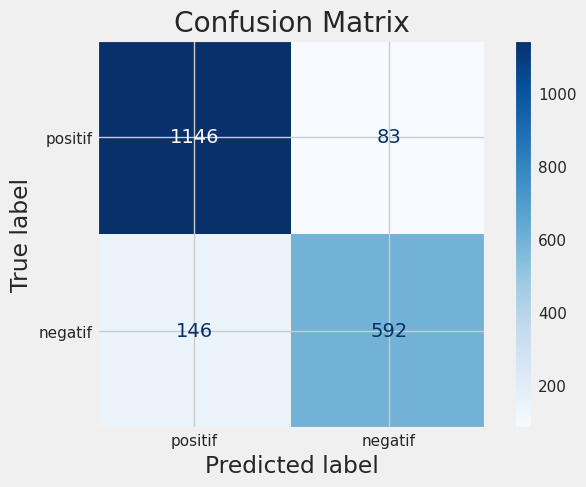

In [32]:
cm = confusion_matrix(y_test, predicted, labels=['positif', 'negatif'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['positif', 'negatif'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

In [33]:
print("\n=== Classification Report ===")
print(classification_report(y_test, predicted, zero_division=0))


=== Classification Report ===
              precision    recall  f1-score   support

     negatif       0.88      0.80      0.84       738
     positif       0.89      0.93      0.91      1229

    accuracy                           0.88      1967
   macro avg       0.88      0.87      0.87      1967
weighted avg       0.88      0.88      0.88      1967

